# Discrete Maps & Hyperbolic Geometry
### `01_Calculus_and_Dynamics/Discrete_Maps_Hyperbolic/`

> **Learning goal:** Master the mathematics of iterated maps — the discrete-time engine that drives autoregressive generation, sampling dynamics, and chaos — then bridge into hyperbolic geometry as the native space for embedding the exponentially branching futures that agents must reason over.

> **Strogatz coverage:** Ch. 10 (1D maps, logistic map, Lyapunov exponents, universality).  
> **Bridge:** Nickel & Kiela (2017), Poincaré Embeddings for Learning Hierarchical Representations.

---

## 1. From Flows to Maps — The Discrete Time Engine

Continuous dynamics: $\dot{x} = f(x)$ — state evolves smoothly in time.  
Discrete dynamics: $x_{n+1} = f(x_n)$ — state jumps in discrete steps.

**Why discrete maps matter for AI:**  
An autoregressive language model is, by definition, an iterated map. At each step the model receives a hidden state $h_n$ and produces the next state $h_{n+1} = F(h_n, \text{token}_n)$. The entire sequence is one long orbit of this map.

### 1A. Fixed Points and the Multiplier

A fixed point $x^*$ satisfies $f(x^*) = x^*$. Stability is governed by the **multiplier**:

$$\lambda = f'(x^*)$$

| Multiplier | Name | Behaviour |
|---|---|---|
| $|\lambda| < 1$ | Stable fixed point | Nearby orbits contract — the system settles |
| $|\lambda| > 1$ | Unstable fixed point | Nearby orbits diverge |
| $\lambda = 0$ | Superstable | Fastest possible convergence |
| $|\lambda| = 1$ | Marginal | Nonlinear terms decide |

**Logistic map fixed points:** $f(x) = rx(1-x)$

- $x^* = 0$: multiplier $= r$. Stable only if $r < 1$.
- $x^* = (r-1)/r$: multiplier $= 2 - r$. Stable iff $|2-r| < 1$, i.e. $1 < r < 3$.

**AI — Repetition Loops:** When an LLM repeats the same phrase indefinitely, its hidden state has settled into a stable fixed point or period-1 cycle: $|\lambda| < 1$. The `repetition_penalty` parameter applies a state-dependent logit discount on already-generated tokens. This is *analogous in effect* to increasing $|\lambda|$ above 1 and destabilising the fixed point — it nudges the orbit out of the attractor — but it is a state-dependent bias, not a literal modification of the map's global slope.

---

## 2. The Logistic Map — Temperature and the Route to Chaos

$$x_{n+1} = r\,x_n(1 - x_n), \qquad x_n \in [0,1], \quad r \in [0,4]$$

As $r$ increases, the system undergoes a sequence of **period-doubling bifurcations**:

| $r$ range | Behaviour |
|---|---|
| $0 < r < 1$ | $x^* = 0$ is the only stable point |
| $1 < r < 3$ | $x^* = (r-1)/r$ stable (single attractor) |
| $3 < r < 3.449$ | Period-2 cycle |
| $3.449 < r < 3.544$ | Period-4 cycle |
| $\vdots$ | Period-doubling cascade |
| $r > r_\infty \approx 3.5699$ | Chaos (with periodic windows) |
| $r = 4$ | Fully chaotic, ergodic on $[0,1]$ |

### 2A. Temperature as a Structural Analogy

The parameter $r$ is *structurally analogous* to the **sampling temperature** $T$ in language generation — both control the transition from deterministic to chaotic behaviour:

| $r$ / Temperature | Regime | LLM Behaviour |
|---|---|---|
| Low $r$ / Low $T$ | Stable fixed point | Greedy decoding — always picks the mode |
| Medium $r$ / Medium $T$ | Period-2/4 cycle | Alternates between a few semantic attractors |
| $r > r_\infty$ / High $T$ | Chaos | Aperiodic, sensitive to the prompt |

> **Important:** This is a *qualitative structural analogy*, not a quantitative equivalence. Sampling temperature divides logits before softmax; the logistic map parameter $r$ scales a quadratic nonlinearity. The behaviours rhyme — they do not map onto each other dimensionally.

---

## 3. The Lyapunov Exponent — Measuring Sensitivity

$$\lambda = \lim_{n \to \infty} \frac{1}{n} \sum_{i=0}^{n-1} \ln |f'(x_i)|$$

This measures the average exponential rate of divergence of nearby orbits:

- $\lambda < 0$: **stable** — perturbations decay, the orbit is predictable
- $\lambda = 0$: **edge of chaos** — marginal sensitivity
- $\lambda > 0$: **chaotic** — nearby orbits diverge exponentially, $\|\delta_n\| \approx e^{\lambda n} \|\delta_0\|$

For the logistic map: $f'(x) = r(1 - 2x)$, so:

$$\lambda = \lim_{n\to\infty} \frac{1}{n}\sum_{i=0}^{n-1} \ln|r(1-2x_i)|$$

**AI — Prompt Robustness:** The Lyapunov exponent is the formal metric for *sensitivity to initial conditions* in generation. If $\lambda > 0$, changing a single comma in the prompt (a perturbation $\delta_0$) can cause the generated essay to diverge completely after enough tokens. The **edge of chaos** ($\lambda \approx 0$) is theoretically optimal: enough flexibility for creative generation, enough stability for coherent output.

> **Note on Period-3 Window:** At $r \approx 3.83$, the Lyapunov exponent *dips negative* — a stable period-3 window embedded inside the chaotic regime. This proves that $\lambda$ is not monotone in $r$ and must be computed, not inferred from $r$ alone.

---

## 4. Universality & Feigenbaum Constants

The period-doubling cascade is **universal**: it occurs in the same quantitative way for *any* smooth unimodal map (not just the logistic map).

### 4A. The Two Constants

Let $r_n$ be the parameter value at which period $2^n$ appears.

**Feigenbaum's $\delta$** — convergence rate of bifurcation parameters:

$$\delta = \lim_{n\to\infty} \frac{r_n - r_{n-1}}{r_{n+1} - r_n} \approx 4.6692016\ldots$$

**Feigenbaum's $\alpha$** — scaling ratio of attractor width at successive doublings:

$$\alpha \approx -2.5029\ldots$$

(Negative because the attractor alternates orientation at each doubling.)

Both constants are **universal** — they are independent of the specific unimodal map. The same $\delta$ and $\alpha$ appear in the sine map, the tent map, the Hénon map, and in physical experiments on Rayleigh–Bénard convection.

### 4B. The Feigenbaum Functional Equation

The universality is explained by a fixed point of the **period-doubling renormalisation operator** $\mathcal{T}$:

$$(\mathcal{T} g)(x) = \frac{1}{\alpha}\,g\bigl(g(\alpha\, x)\bigr)$$

The fixed point $g^*$ satisfies:

$$\boxed{g(x) = \frac{1}{\alpha}\,g\bigl(g(\alpha\, x)\bigr), \qquad \alpha \approx -2.5029}$$

Since $\alpha < 0$, the prefactor $1/\alpha$ is negative — this encodes the orientation flip at each doubling. This equation says: **the shape of the map after two doublings, rescaled by $\alpha$, is identical to the original**. This self-referential structure is what forces universality.

> **AI — Scaling Laws (research frontier):** Neural network scaling laws (Hoffmann et al. 2022; Kaplan et al. 2020) show that loss $\propto N^{-\alpha}$ in compute $N$ — a power law universal across architectures. Recent work (Peraza Coppola et al., 2025) applies RG-style analysis to learning curves and finds universality governed by a Gaussian-Process fixed point. The mathematical machinery is the same renormalisation framework — the *qualitative* connection is real and actively researched, though a direct quantitative mapping between Feigenbaum's $\delta$ and AI scaling exponents has not been established.

---

## 5. The Hyperbolic Bridge — Embedding Branching Futures

### 5A. Why Euclidean Space Fails for Trees

Consider a binary tree of depth $n$: it has $2^n$ leaves. The total number of nodes is $2^{n+1} - 1$. To embed this tree in $\mathbb{R}^d$ with distances proportional to graph distance, you need exponentially many dimensions — or accept massive **distortion**.

**Formal result (Linial et al., 1994):** Any embedding of an $n$-node tree into $\mathbb{R}^d$ with $O(1)$ distortion requires $d = \Omega(\log n)$ dimensions.

When an LLM does **beam search** or **MCTS**, it is exploring a tree of possible futures of depth $T$ and branching factor $b$: $b^T$ leaves. For $b=50$, $T=20$: that's $50^{20} \approx 10^{34}$ leaf nodes. Euclidean embeddings of this tree will be crushed.

### 5B. Hyperbolic Geometry — Space That Grows Exponentially

In the **Poincaré disk** $\mathbb{D} = \{z \in \mathbb{R}^2 : \|z\| < 1\}$, the hyperbolic metric is:

$$d_H(u, v) = \text{arcosh}\!\left(1 + \frac{2\|u-v\|^2}{(1-\|u\|^2)(1-\|v\|^2)}\right)$$

Key properties:
- The boundary $\|z\| = 1$ is infinitely far away — it represents ideal points at infinity
- The circumference of a hyperbolic circle of radius $R$ is $C(R) = 2\pi \sinh(R) \approx \pi e^R$ for large $R$
- Volume grows *exponentially* with radius — matching the exponential growth of trees

**The result (Nickel & Kiela, NeurIPS 2017):** Any finite tree can be embedded in the 2D Poincaré disk with arbitrarily low distortion. The root goes at the origin; children are placed further from the center; siblings are angularly separated. In experiments on the WordNet noun hierarchy (82,115 nodes), Poincaré embeddings in **2 dimensions** achieved MAP 0.853, outperforming Euclidean embeddings in 200 dimensions (MAP 0.087).

**Poincaré GloVe (Tifrea et al., ICLR 2019):** Hyperbolic word embeddings outperform Euclidean ones on hypernymy detection (word A *is a* word B) because "is-a" relationships are inherently tree-structured.

### 5C. Why This Matters for Causal Reasoning Agents

A causal reasoning agent building a **World Model** must represent:

| Structure | Embedding Space |
|---|---|
| Semantic similarity | Euclidean or cosine space |
| Hierarchical ontology (is-a, part-of) | Hyperbolic / Poincaré ball |
| Temporal causal chains | Minkowski spacetime (hyperbolic structure) |
| Beam search / MCTS tree | Poincaré disk (exponential branching) |

The node closest to the **origin** of the Poincaré disk is the most general concept (highest in the hierarchy). Nodes near the **boundary** are the most specific. Distance from the origin naturally encodes *generality* — this emerges from the geometry without supervision.

---

## 6. Code — Five Implementations

### 6A. Cobweb Diagram + Stability Audit


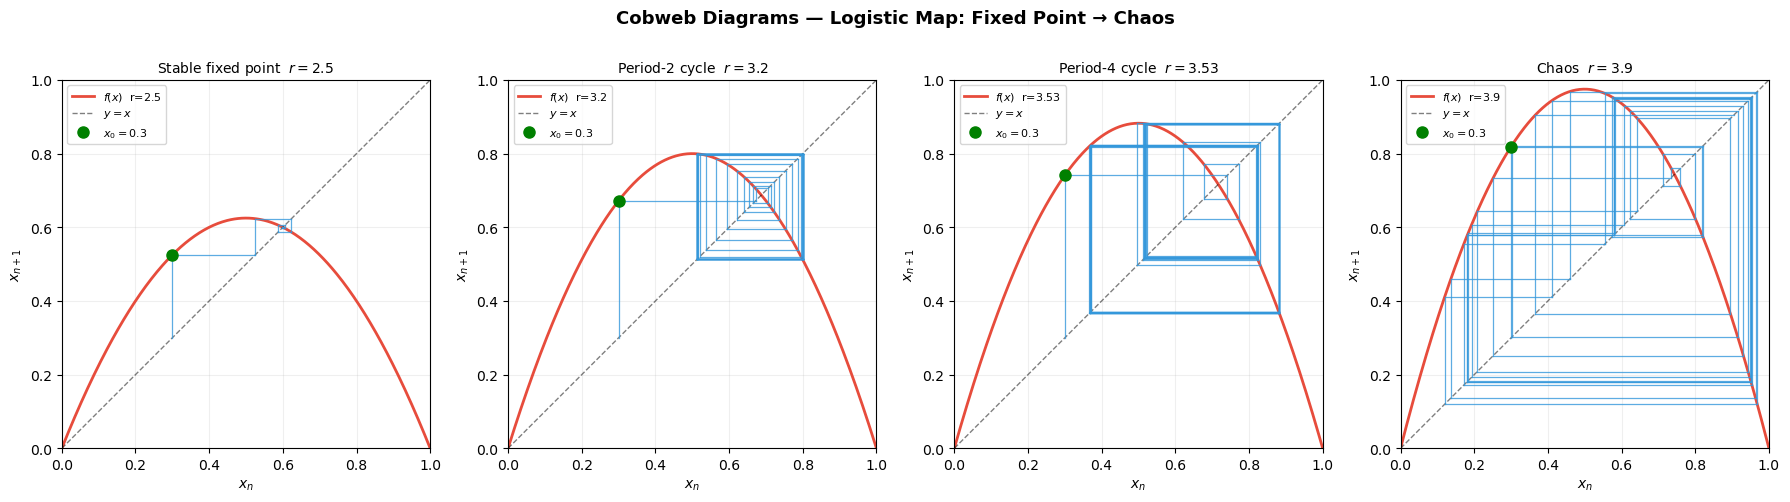

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, r):
    return r * x * (1 - x)

def cobweb(ax, f, r, x0, n_steps=40, x_range=(0,1)):
    xs = np.linspace(*x_range, 400)
    ax.plot(xs, [f(x, r) for x in xs], color="#E74C3C", lw=2, label=f"$f(x)$  r={r}")
    ax.plot(xs, xs, "k--", lw=1, alpha=0.5, label="$y = x$")

    x = x0
    for _ in range(n_steps):
        fx = f(x, r)
        ax.plot([x, x],  [x, fx], color="#3498DB", lw=0.9, alpha=0.8)   # vertical
        ax.plot([x, fx], [fx, fx], color="#3498DB", lw=0.9, alpha=0.8)  # horizontal
        x = fx

    ax.plot(x0, f(x0, r), "go", ms=8, zorder=5, label=f"$x_0={x0}$")
    ax.set_xlim(*x_range); ax.set_ylim(*x_range)
    ax.set_xlabel("$x_n$"); ax.set_ylabel("$x_{n+1}$")
    ax.set_aspect("equal"); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

r_cases = [
    (2.5,  0.3, "Stable fixed point  $r=2.5$"),
    (3.2,  0.3, "Period-2 cycle  $r=3.2$"),
    (3.53, 0.3, "Period-4 cycle  $r=3.53$"),
    (3.9,  0.3, "Chaos  $r=3.9$"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Cobweb Diagrams — Logistic Map: Fixed Point → Chaos",
             fontsize=13, fontweight="bold")
for ax, (r, x0, title) in zip(axes, r_cases):
    cobweb(ax, logistic_map, r, x0)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig("6A_cobweb.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 6B. Bifurcation Diagram + Lyapunov Exponent


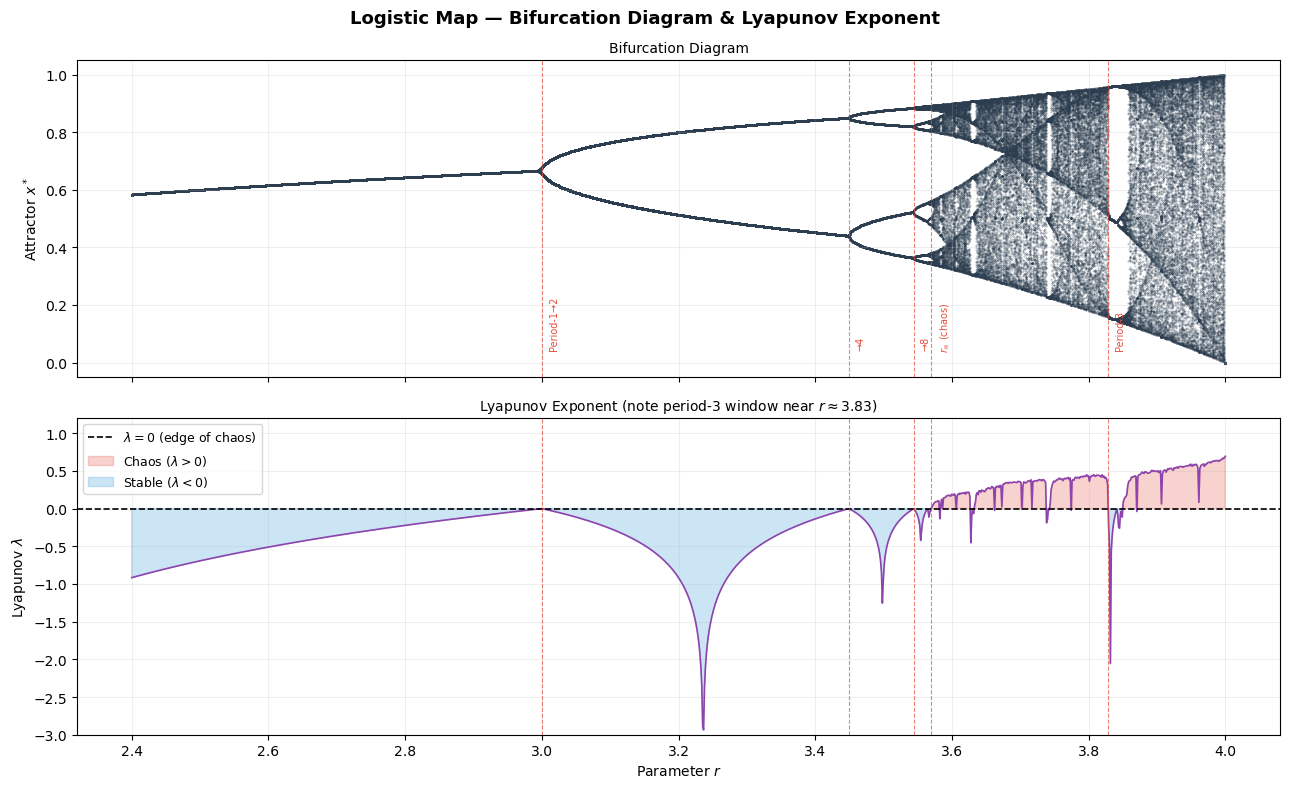

r      |  lambda  | Regime
--------------------------------------
r=2.50 | -0.6931  | Stable (fixed)
r=3.20 | -0.9163  | Stable (period-2)
r=3.50 | -0.8725  | Stable (period-4)
r=3.83 | -0.3705  | Period-3 window
r=3.90 | +0.4884  | Chaotic
r=4.00 | +0.6934  | Fully chaotic


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, r):
    return r * x * (1 - x)

def compute_lyapunov(r_val, x0=0.1, n_transient=500, n_iter=2000):
    """
    Computes Lyapunov exponent for the logistic map.

    Formula:
    λ = (1/n) * Σ ln|f'(x_i)|
    where f'(x) = r(1 - 2x)
    """
    x = x0

    # Remove transient behavior
    for _ in range(n_transient):
        x = logistic_map(x, r_val)

    lyap = 0.0

    # Compute Lyapunov exponent
    for _ in range(n_iter):
        deriv = abs(r_val * (1 - 2 * x)) + 1e-12  # avoid log(0)
        lyap += np.log(deriv)
        x = logistic_map(x, r_val)

    return lyap / n_iter


r_vals   = np.linspace(2.4, 4.0, 1200)
n_trans  = 500
n_plot   = 200

# Bifurcation data
bif_r, bif_x = [], []
for r in r_vals:
    x = 0.5
    for _ in range(n_trans):
        x = logistic_map(x, r)
    for _ in range(n_plot):
        x = logistic_map(x, r)
        bif_r.append(r)
        bif_x.append(x)

# Lyapunov data
lyap_vals = np.array([compute_lyapunov(r) for r in r_vals])

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Logistic Map — Bifurcation Diagram & Lyapunov Exponent",
             fontsize=13, fontweight="bold")

# Bifurcation diagram
ax1.scatter(bif_r, bif_x, s=0.15, color="#2C3E50", alpha=0.4)
ax1.set_ylabel("Attractor $x^*$")
ax1.set_title("Bifurcation Diagram", fontsize=10)
ax1.grid(True, alpha=0.2)

# Annotate key transitions
for r_mark, lbl in [
    (3.0, "Period-1→2"),
    (3.449, "→4"),
    (3.544, "→8"),
    (3.5699, "$r_\\infty$ (chaos)"),
    (3.828, "Period-3")
]:
    ax1.axvline(r_mark, color="#E74C3C", lw=0.8, ls="--", alpha=0.7)
    ax1.text(r_mark + 0.01, 0.05, lbl, fontsize=7, rotation=90, color="#E74C3C")

# Lyapunov exponent
ax2.plot(r_vals, lyap_vals, color="#8E44AD", lw=1.2)
ax2.axhline(0, color="black", lw=1.2, ls="--", label="$\\lambda = 0$ (edge of chaos)")

ax2.fill_between(r_vals, lyap_vals, 0,
                 where=(lyap_vals > 0),
                 color="#E74C3C", alpha=0.25,
                 label="Chaos ($\\lambda>0$)")

ax2.fill_between(r_vals, lyap_vals, 0,
                 where=(lyap_vals < 0),
                 color="#3498DB", alpha=0.25,
                 label="Stable ($\\lambda<0$)")

ax2.set_ylabel("Lyapunov $\\lambda$")
ax2.set_xlabel("Parameter $r$")
ax2.set_title("Lyapunov Exponent (note period-3 window near $r\\approx3.83$)",
              fontsize=10)
ax2.set_ylim(-3, 1.2)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

for r_mark in [3.0, 3.449, 3.544, 3.5699, 3.828]:
    ax2.axvline(r_mark, color="#E74C3C", lw=0.8, ls="--", alpha=0.7)

plt.tight_layout()
plt.savefig("6B_bifurcation_lyapunov.png", dpi=150, bbox_inches="tight")
plt.show()

# Print table
print("r      |  lambda  | Regime")
print("-" * 38)
for r_t, desc in [
    (2.5, "Stable (fixed)"),
    (3.2, "Stable (period-2)"),
    (3.5, "Stable (period-4)"),
    (3.83, "Period-3 window"),
    (3.9, "Chaotic"),
    (4.0, "Fully chaotic")
]:
    lam = compute_lyapunov(r_t)
    print(f"r={r_t:4.2f} | {lam:+.4f}  | {desc}")

---

### 6C. Feigenbaum Universality — Measuring $\delta$ Numerically


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def find_period_n_onset(map_func, n_period, r_lo=2.9, r_hi=4.0,
                        n_trans=2000, n_check=200, tol=1e-6):
    
    for _ in range(60):
        r_mid = (r_lo + r_hi) / 2
        x = 0.5
        for _ in range(n_trans):
            x = map_func(x, r_mid)
        # Check if orbit has period dividing n_period
        x0 = x
        for _ in range(n_period):
            x = map_func(x, r_mid)
        if abs(x - x0) < tol:
            r_hi = r_mid
        else:
            r_lo = r_mid
    return (r_lo + r_hi) / 2

def logistic_map(x, r): return r * x * (1 - x)
def sine_map(x, r):     return r * np.sin(np.pi * x)   # another unimodal map

print("Computing period-doubling onset values r_n (logistic map)...")
periods = [2, 4, 8, 16]
# Known values for logistic map
r_known = [3.0, 3.44949, 3.54409, 3.56441, 3.5688]
r_onsets_log = []
for p, r_lo in zip(periods, [2.9, 3.4, 3.5, 3.55]):
    r_on = find_period_n_onset(logistic_map, p, r_lo=r_lo, r_hi=r_lo+0.2)
    r_onsets_log.append(r_on)
    print(f"  Period-{p:2d}: r = {r_on:.6f}")

print("\nFeigenbaum delta estimates (logistic map):")
for i in range(1, len(r_onsets_log)-1):
    if r_onsets_log[i+1] - r_onsets_log[i] > 0:
        delta_est = (r_onsets_log[i] - r_onsets_log[i-1]) / \
                    (r_onsets_log[i+1] - r_onsets_log[i])
        print(f"  delta({i},{i+1}) = {delta_est:.4f}  (true: 4.6692)")

# Bifurcation tree visualization
r_fine = np.linspace(2.8, 4.0, 3000)
n_trans = 800; n_plot = 150
bif_r, bif_x = [], []
for r in r_fine:
    x = 0.5
    for _ in range(n_trans): x = logistic_map(x, r)
    for _ in range(n_plot):
        x = logistic_map(x, r)
        bif_r.append(r); bif_x.append(x)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(bif_r, bif_x, s=0.1, color="#2C3E50", alpha=0.35)
for r_on in r_onsets_log:
    ax.axvline(r_on, color="#E74C3C", lw=1, ls=":", alpha=0.8)
ax.set_xlabel("$r$"); ax.set_ylabel("$x^*$")
ax.set_title(f"Logistic Map Bifurcation Tree\n"
             f"$\delta \approx 4.6692$ — ratio of successive interval widths",
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("6C_feigenbaum.png", dpi=150, bbox_inches="tight")
plt.show()


<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nisar\AppData\Local\Temp\ipykernel_9884\3325280775.py:59: SyntaxWarning: invalid escape sequence '\d'
  f"$\delta \approx 4.6692$ — ratio of successive interval widths",


Computing period-doubling onset values r_n (logistic map)...
  Period- 2: r = 3.000614
  Period- 4: r = 3.400000
  Period- 8: r = 3.700000
  Period-16: r = 3.750000

Feigenbaum delta estimates (logistic map):
  delta(1,2) = 1.3313  (true: 4.6692)
  delta(2,3) = 6.0000  (true: 4.6692)


ValueError: 
$\delta pprox 4.6692$ — ratio of successive interval widths
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x0000024659BBCF40> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\delta pprox 4.6692$ — ratio of successive interval widths
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\delta pprox 4.6692$ — ratio of successive interval widths
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1200x500 with 1 Axes>

---

### 6D. Poincaré Disk — Actual Hyperbolic Geometry

> The original document's "Hyperbolic Bifurcation Projector" used a standard polar coordinate remap — that is *not* hyperbolic geometry. Below is the real Poincaré disk with the correct hyperbolic metric, demonstrating why trees embed naturally in it.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Poincaré disk utilities ───────────────────────────────────────────────────
def poincare_dist(u, v):
    \"\"\"Hyperbolic distance in the Poincaré disk.\"\"\"
    norm_u2 = np.dot(u, u)
    norm_v2 = np.dot(v, v)
    diff2   = np.dot(u - v, u - v)
    arg     = 1.0 + 2.0 * diff2 / ((1 - norm_u2) * (1 - norm_v2))
    return np.arccosh(np.clip(arg, 1.0, None))

def poincare_geodesic(u, v, n=100):
    \"\"\"
    Geodesic between u and v in the Poincaré disk.
    Uses the Möbius transformation: map u to origin, draw diameter, map back.
    \"\"\"
    # Möbius transformation sending u -> 0
    def mobius(z, a):
        num = z - a
        den = 1 - np.conj(a) * z
        return num / den

    u_c = u[0] + 1j*u[1]
    v_c = v[0] + 1j*v[1]
    v_mapped = mobius(v_c, u_c)

    # Straight line from 0 to v_mapped in transformed space
    t = np.linspace(0, 1, n)
    line = t * v_mapped

    # Map back: inverse Möbius (a -> 0 sends z -> (z + a)/(1 + conj(a)*z))
    def inv_mobius(z, a):
        return (z + a) / (1 + np.conj(a) * z)

    curve = inv_mobius(line, u_c)
    return np.column_stack([curve.real, curve.imag])

def embed_tree_poincare(branching=2, depth=4, scale=0.45):
    \"\"\"
    Embed a regular tree in the Poincaré disk.
    Root at origin; each level has children arranged angularly around parent.
    \"\"\"
    nodes = {0: np.array([0.0, 0.0])}
    edges = []
    parent_map = {}
    node_id = 1
    current_level = [0]

    for level in range(1, depth + 1):
        next_level = []
        for parent in current_level:
            p_pos = nodes[parent]
            parent_angle = np.arctan2(p_pos[1], p_pos[0]) if np.linalg.norm(p_pos) > 1e-8 else 0

            for k in range(branching):
                angle = parent_angle + (k - (branching-1)/2) * (np.pi / (branching * level))
                # Push further from center each level: r = 1 - exp(-scale * level)
                r = 1.0 - np.exp(-scale * level)
                child_pos = np.array([r * np.cos(angle), r * np.sin(angle)])
                nodes[node_id] = child_pos
                edges.append((parent, node_id))
                parent_map[node_id] = parent
                next_level.append(node_id)
                node_id += 1
        current_level = next_level

    return nodes, edges

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Poincaré Disk — Hyperbolic Geometry for Tree Embeddings",
             fontsize=13, fontweight="bold")

# ── Panel 1: Poincaré disk geometry properties ───────────────────────────────
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5, label="Boundary (∞)")
ax.fill(np.cos(theta), np.sin(theta), alpha=0.04, color="blue")

# Concentric circles in hyperbolic radius
for R, c in [(0.5,"#3498DB"),(1.0,"#E74C3C"),(1.5,"#2ECC71"),(2.0,"#F39C12")]:
    r_euc = np.tanh(R/2)     # Euclidean radius in Poincare disk for hyperbolic radius R
    circ = plt.Circle((0,0), r_euc, fill=False, color=c, lw=1.2,
                       label=f"Hyperbolic R={R}  (Euclid r={r_euc:.2f})")
    ax.add_patch(circ)

ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.set_title("Concentric circles in\nhyperbolic vs Euclidean radius", fontsize=9)
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.2)
ax.text(0.0, -0.72, "Same $\Delta R$,\nsmaller Euclidean gap", ha="center", fontsize=8)

# ── Panel 2: Tree embedded in Poincaré disk ───────────────────────────────────
ax2 = axes[1]
ax2.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5)
ax2.fill(np.cos(theta), np.sin(theta), alpha=0.04, color="blue")

nodes, edges = embed_tree_poincare(branching=3, depth=4, scale=0.55)

for (p, c) in edges:
    geo = poincare_geodesic(nodes[p], nodes[c], n=60)
    ax2.plot(geo[:,0], geo[:,1], "b-", lw=1.0, alpha=0.6)

for nid, pos in nodes.items():
    depth_n = 0
    tmp = nid
    while tmp in {c: p for p,c in edges}:
        tmp = {c: p for p,c in edges}[tmp]
        depth_n += 1
    color = plt.cm.RdYlGn(1 - depth_n/5)
    ax2.plot(pos[0], pos[1], "o", color=color, ms=5, zorder=3)

ax2.set_xlim(-1.1, 1.1); ax2.set_ylim(-1.1, 1.1); ax2.set_aspect("equal")
ax2.set_title("Ternary tree (depth 4) embedded\nin the Poincaré disk via geodesics", fontsize=9)
ax2.grid(True, alpha=0.15)
ax2.text(0.0, 0.0, "Root", ha="center", va="center", fontsize=8, color="darkred",
         fontweight="bold")

# ── Panel 3: Euclidean vs hyperbolic tree capacity ───────────────────────────
ax3 = axes[2]
depths   = np.arange(1, 12)
branches = 2
n_nodes  = branches**depths   # nodes at depth d

# Euclidean: area grows as pi*r^2, need ~2^d nodes at distance d
r_euclid = np.sqrt(n_nodes / np.pi)   # radius needed to "fit" 2^d non-overlapping points

# Hyperbolic: circumference grows as pi*e^R — fit 2^d nodes at R = log(2)*d
R_hyper = np.log(branches) * depths

ax3.semilogy(depths, r_euclid, "r-o", lw=2, ms=6, label="Euclidean radius needed")
ax3.semilogy(depths, R_hyper,  "b-s", lw=2, ms=6, label="Hyperbolic radius needed")
ax3.set_xlabel("Tree depth $d$")
ax3.set_ylabel("Radius required (log scale)")
ax3.set_title("Space needed to embed a binary tree\n"
              "Hyperbolic grows $O(d)$, Euclidean grows $O(2^{d/2})$", fontsize=9)
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("6D_poincare_disk.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 6E. Polar Bifurcation Visualization (Correctly Labelled)

> This is the polar-coordinate remapping from the original document — it is a *beautiful visualization*, but it is standard polar coordinates, not the Poincaré disk metric. Correctly labelled here.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(x, r): return r * x * (1 - x)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
ax.set_ylim(0, 1)
ax.set_theta_zero_location("N")
ax.grid(True, alpha=0.15)

r_vals = np.linspace(2.5, 4.0, 1500)
n_trans, n_plot = 300, 60

for r in r_vals:
    x = 0.5
    for _ in range(n_trans):
        x = logistic_map(x, r)
    for _ in range(n_plot):
        x = logistic_map(x, r)
        # r -> normalised radius in [0,1], x -> angle in [0, 2pi]
        hyperbolic_radius = (r - 2.5) / 1.5
        angle = x * 2 * np.pi
        ax.plot(angle, hyperbolic_radius, "k.", markersize=0.12, alpha=0.5)

# Annotate regimes
for r_mark, lbl, color in [(3.0,"Period-2","#E74C3C"),(3.449,"Period-4","#E67E22"),
                            (3.5699,"Chaos onset","#9B59B6"),(3.828,"Period-3 window","#2ECC71")]:
    rad = (r_mark - 2.5) / 1.5
    ax.axhline(rad, color=color, lw=1.0, ls="--", alpha=0.7)
    ax.text(np.pi/4, rad+0.02, lbl, fontsize=8, color=color)

ax.set_title("Polar Visualization of the Logistic Bifurcation Diagram\n"
             "(radius = $r$, angle = orbit state $x_n$)\n"
             "Note: this is polar coordinates, NOT Poincaré disk geometry",
             fontsize=10, pad=20)
plt.tight_layout()
plt.savefig("6E_polar_bifurcation.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 7. Concept Map

```
Discrete Maps & Hyperbolic Geometry
│
├── 1D Iterated Maps  x_{n+1} = f(x_n)
│   ├── Fixed points: f(x*) = x*
│   ├── Stability: |lambda| = |f'(x*)| determines convergence
│   └── AI: autoregressive generation is an iterated map
│
├── Logistic Map  x_{n+1} = rx(1-x)
│   ├── r < 3      → stable fixed point   (greedy decoding)
│   ├── 3 < r < 3.57 → period-doubling cascade (sampling modes)
│   └── r > 3.57   → chaos                (high-temperature hallucination)
│
├── Lyapunov Exponent  lambda = (1/n) sum ln|f'(x_i)|
│   ├── lambda < 0 → stable, predictable
│   ├── lambda = 0 → edge of chaos (optimal generation?)
│   └── lambda > 0 → chaotic, sensitive to prompt
│
├── Feigenbaum Universality
│   ├── delta ≈ 4.6692  (parameter convergence ratio)
│   ├── alpha ≈ -2.5029  (attractor width ratio)
│   ├── Functional equation: g(x) = (1/alpha) * g(g(alpha*x))
│   └── AI link: qualitative connection to neural scaling laws (active research)
│
└── Hyperbolic Geometry
    ├── Poincaré disk: unit disk with d_H = arcosh(1 + 2||u-v||^2/((1-||u||^2)(1-||v||^2)))
    ├── Circumference C(R) = 2pi*sinh(R) ~ pi*e^R (exponential growth)
    ├── Trees embed in 2D Poincaré disk with near-zero distortion
    ├── Nickel & Kiela 2017: WordNet in 2D hyperbolic >> 200D Euclidean
    └── AI: beam search / MCTS trees, hierarchical ontologies, causal DAGs
```

---

## 8. Summary Table

| Concept | Formula | AI / ML Relevance |
|---|---|---|
| Multiplier | $\lambda = f'(x^*)$ | $|\lambda| < 1$ → repetition trap; $>1$ → orbit escapes |
| Logistic map period-1 stability | $1 < r < 3$ | Greedy / deterministic decoding regime |
| Chaos onset | $r_\infty \approx 3.5699$ | Structural analogue of high-temperature hallucination |
| Lyapunov exponent | $\lambda = \frac{1}{n}\sum \ln\|f'(x_i)\|$ | Prompt sensitivity / coherence metric |
| Feigenbaum $\delta$ | $\approx 4.6692$ | Universal parameter-space convergence ratio |
| Feigenbaum equation | $g(x)=\frac{1}{\alpha}g(g(\alpha x))$ | Self-similar fixed point of period-doubling operator |
| Poincaré distance | $\text{arcosh}(1 + \frac{2\|u-v\|^2}{(1-\|u\|^2)(1-\|v\|^2)})$ | True hyperbolic distance for tree embeddings |
| Hyperbolic capacity | $C(R) \sim \pi e^R$ | Exponential branching fits in $O(d)$ radius |

---

## 9. References

- Strogatz, S. H. — *Nonlinear Dynamics and Chaos*, Ch. 10
- Feigenbaum, M. J. (1978) — *Quantitative Universality for a Class of Nonlinear Transformations*, J. Stat. Phys. 19
- Feigenbaum, M. J. (1979) — *The Universal Metric Properties of Nonlinear Transformations*, J. Stat. Phys. 21
- Nickel, M. & Kiela, D. (2017) — *Poincaré Embeddings for Learning Hierarchical Representations*, NeurIPS
- Tifrea, A., Bécigneul, G. & Ganea, O. (2019) — *Poincaré GloVe: Hyperbolic Word Embeddings*, ICLR
- Sala, F. et al. (2018) — *Representation Tradeoffs for Hyperbolic Embeddings*, ICML
- Kaplan, J. et al. (2020) — *Scaling Laws for Neural Language Models*, arXiv 2001.08361
- Peraza Coppola, G. et al. (2025) — *Renormalization Group for Deep Neural Networks*, arXiv 2510.25553
